#Анализ вакансий для аналитика данных
###Цель: понять требования рынка и зарплаты.

###Загрузка необходимых библиотек и датасета данных

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

file_path = '/content/sample_data/vacancies.csv'
df = pd.read_csv(file_path)

print("Данные загружены. Размер:", df.shape)
print(df.head())

Данные загружены. Размер: (31126, 25)
   premium  has_test  response_letter_required  archived     schedule  \
0    False     False                     False      True  Полный день   
1    False     False                     False     False  Полный день   
2    False     False                     False     False  Полный день   
3    False     False                     False     False  Полный день   
4    False     False                     False     False  Полный день   

   accept_temporary          professional_roles  accept_incomplete_resumes  \
0              True                   Монтажник                      False   
1             False                   Бухгалтер                      False   
2             False  Технический директор (CTO)                      False   
3             False                   Бухгалтер                      False   
4             False  Руководитель отдела продаж                      False   

           experience        employment  ...  has_emai

###Очистка и предобработка данных

In [49]:
# Удалим дубликаты
df = df.drop_duplicates()

print("Пропущенные значения:")
print(df.isnull().sum())

# Оставим только вакансии с зарплатой
df_salary = df[df['salary'].notna()].copy()
print(f"\nВакансий с указанной зарплатой: {len(df_salary)}")

# Оставим основные колонки
df_clean = df_salary[['salary', 'experience', 'schedule', 'employment', 'professional_roles', 'AO']].copy()
df_clean.columns = ['зарплата', 'опыт', 'график', 'занятость', 'роль', 'округ']

Пропущенные значения:
premium                          0
has_test                         0
response_letter_required         0
archived                         0
schedule                         0
accept_temporary                 0
professional_roles               0
accept_incomplete_resumes        0
experience                       0
employment                       0
is_adv_vacancy                   0
employer_trusted                 0
employer_type                   45
industries_count                45
vacancies_count                 45
has_email                        0
phones_count                     0
vacancy_type                     0
lat                           3309
lon                           3309
industry                         0
stations_within_km            3410
distance_to_the_nearest(m)    3410
AO                               0
salary                           0
dtype: int64

Вакансий с указанной зарплатой: 17208


###Анализ заработных плат

Средняя зарплата: 106,296 ₽
Медианная зарплата: 87,870 ₽
Минимальная: 41 ₽
Максимальная: 57,425,633 ₽


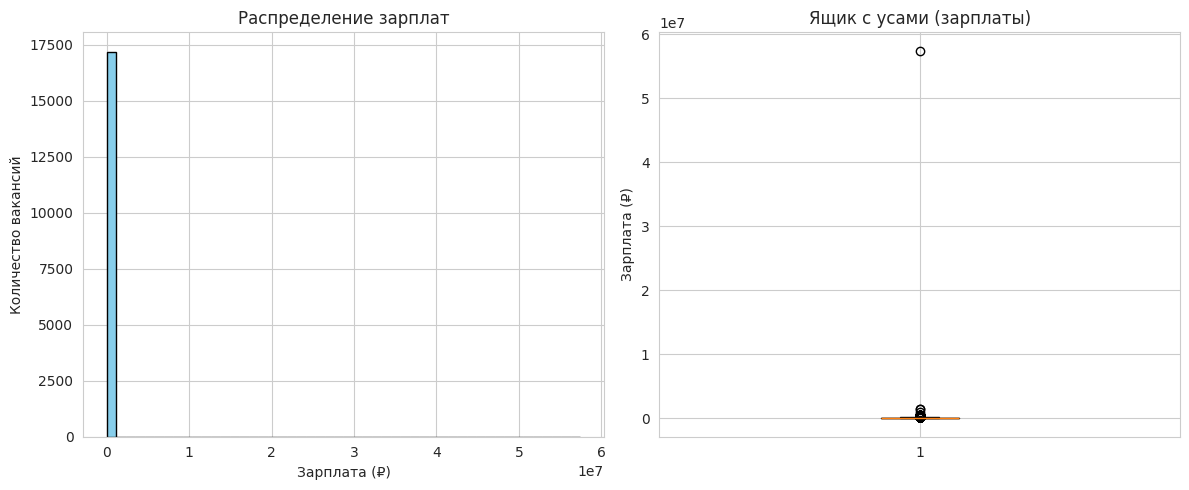

In [50]:
print(f"Средняя зарплата: {df_salary['salary'].mean():,.0f} ₽")
print(f"Медианная зарплата: {df_salary['salary'].median():,.0f} ₽")
print(f"Минимальная: {df_salary['salary'].min():,.0f} ₽")
print(f"Максимальная: {df_salary['salary'].max():,.0f} ₽")

# Распределение зарплат
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_salary['salary'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение зарплат')
plt.xlabel('Зарплата (₽)')
plt.ylabel('Количество вакансий')

plt.subplot(1, 2, 2)
plt.boxplot(df_salary['salary'])
plt.title('Ящик с усами (зарплаты)')
plt.ylabel('Зарплата (₽)')
plt.tight_layout()
plt.show()

###Анализ по округам


	ТОП-10 округов по количеству вакансий
                количество  средняя_зарплата
округ                                       
Не в Москве           5383     108356.557338
ЮАО                   1816     103018.632731
ЦАО                   1602     137253.156420
ЮВАО                  1347      97570.580379
САО                   1262     102877.917231
ЗАО                   1253     103702.419593
ВАО                   1234      94990.128829
СВАО                  1220      96869.722910
ЮЗАО                   842      98576.920428
Новомосковский         676     100744.666635


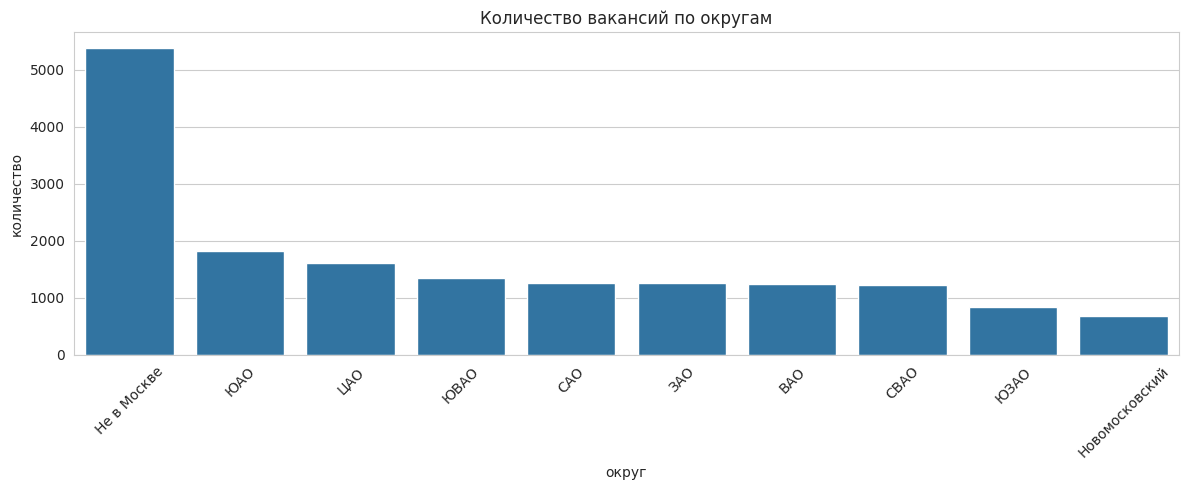

In [51]:
# Анализ по округам (вместо городов)
city_stats = df_clean.groupby('округ').agg(
    количество=('зарплата', 'count'),
    средняя_зарплата=('зарплата', 'mean')
).sort_values('количество', ascending=False).head(10)

print("\n\tТОП-10 округов по количеству вакансий")
print(city_stats)

plt.figure(figsize=(12, 5))
sns.barplot(data=city_stats.reset_index(), x='округ', y='количество')
plt.title('Количество вакансий по округам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Анализ по графику работы

In [52]:
schedule_stats = df_clean.groupby('график').agg(
    количество=('зарплата', 'count'),
    средняя_зарплата=('зарплата', 'mean')
).sort_values('количество', ascending=False)

print("\n\tСтатистика")
print(schedule_stats)


	Статистика
                  количество  средняя_зарплата
график                                        
Полный день            11922     108529.781931
Сменный график          3687      88591.885982
Гибкий график            765     135185.395791
Удаленная работа         432     115395.033634
Вахтовый метод           402     137671.092923


###Анализ по профессиональным ролям


	ТОП-10 ролей по количеству вакансий
                                                    количество  \
роль                                                             
Менеджер по продажам, менеджер по работе с клие...        2367   
Другое                                                    1433   
Водитель                                                  1304   
Кладовщик                                                  861   
Курьер                                                     814   
Автослесарь, автомеханик                                   627   
Продавец-консультант, продавец-кассир                      560   
Упаковщик, комплектовщик                                   533   
Бухгалтер                                                  497   
Менеджер по логистике, менеджер по ВЭД                     485   

                                                    средняя_зарплата  
роль                                                                  
Менеджер по продажам, менед

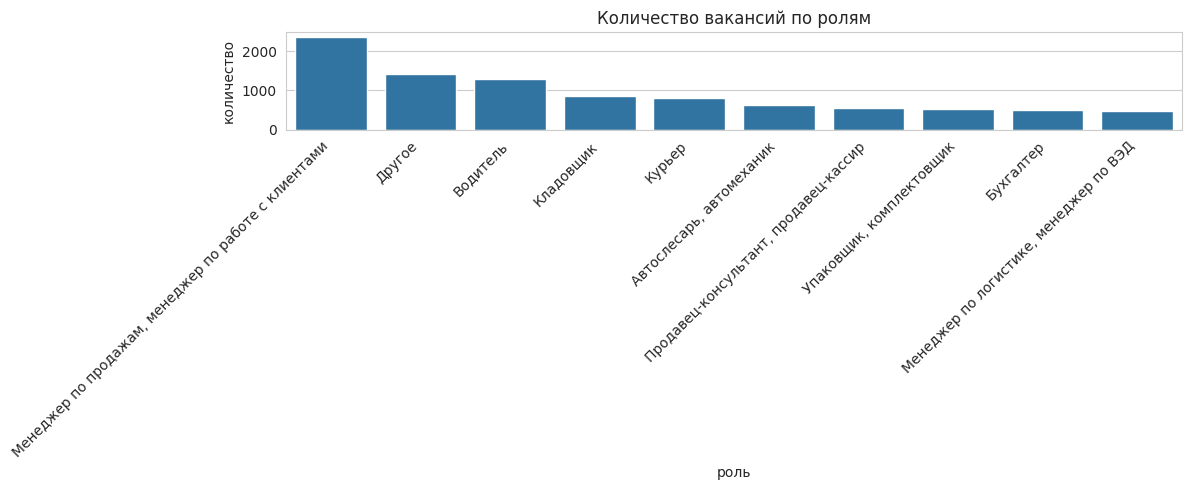

In [53]:
role_stats = df_clean.groupby('роль').agg(
    количество=('зарплата', 'count'),
    средняя_зарплата=('зарплата', 'mean')
).sort_values('количество', ascending=False).head(10)

print("\n\tТОП-10 ролей по количеству вакансий")
print(role_stats)

plt.figure(figsize=(12, 5))
sns.barplot(data=role_stats.reset_index(), x='роль', y='количество')
plt.title('Количество вакансий по ролям')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Анализ по опыту

In [54]:
exp_stats = df_clean.groupby('опыт').agg(
    количество=('зарплата', 'count'),
    средняя_зарплата=('зарплата', 'mean')
).sort_values('количество', ascending=False)

print(exp_stats)

                    количество  средняя_зарплата
опыт                                            
От 1 года до 3 лет        7748     104337.032207
Нет опыта                 6634      87408.124398
От 3 до 6 лет             2569     153803.769387
Более 6 лет                257     178019.062685


###Выводы и рекомендации

In [56]:
print(f"""
Факты по данным выборки:
• Всего вакансий в выборке: {len(df_clean):,}
• Средняя зарплата: {df_clean['зарплата'].mean():,.0f} ₽
• Медианная зарплата: {df_clean['зарплата'].median():,.0f} ₽

По округам:
• Больше всего вакансий в округе: {city_stats.index[0]} ({city_stats.iloc[0]['количество']} шт.)
• Самая высокая средняя зарплата среди топ-10 округов: {city_stats['средняя_зарплата'].max():,.0f} ₽

По опыту:
• Доля вакансий без опыта: {exp_stats.loc['Нет опыта', 'количество']/len(df_clean)*100:.1f}%
• Средняя зарплата без опыта: {exp_stats.loc['Нет опыта', 'средняя_зарплата']:,.0f} ₽

Рекомендации:
• Целевой округ: {city_stats.index[0]} (больше всего вакансий)
• Ожидаемая зарплата на старте: ~{exp_stats.loc['Нет опыта', 'средняя_зарплата']:,.0f} ₽
• Через 1-2 года опыта рост до ~{exp_stats.loc['От 1 года до 3 лет', 'средняя_зарплата']:,.0f} ₽
• Удалёнка / гибрид: проверь вакансии с графиком "Удаленная работа"
""")


Факты по данным выборки:
• Всего вакансий в выборке: 17,208
• Средняя зарплата: 106,296 ₽
• Медианная зарплата: 87,870 ₽

По округам:
• Больше всего вакансий в округе: Не в Москве (5383.0 шт.)
• Самая высокая средняя зарплата среди топ-10 округов: 137,253 ₽

По опыту:
• Доля вакансий без опыта: 38.6%
• Средняя зарплата без опыта: 87,408 ₽

Рекомендации:
• Целевой округ: Не в Москве (больше всего вакансий)
• Ожидаемая зарплата на старте: ~87,408 ₽
• Через 1-2 года опыта рост до ~104,337 ₽
• Удалёнка / гибрид: проверь вакансии с графиком "Удаленная работа"

